# SCOPe family assignment benchmark

## Description

Using viral subset of the SCOPe dataset, we assess the performance of ESM3Di versus ProstT5 in assigning domains to the correct category.

This is a reproduced version of the identical benchmark used in Foldseek paper, therefore please refer to the paper ([link](https://www.nature.com/articles/s41587-023-01773-0)) for detailed description of the benchmark (Methods - SCOPe benchmark).

---

## SCOPe Dataset preparation

### Download SCOPe40 dataset

In [ ]:
%%bash
mkdir -p data/scope
wget --no-check-certificate -q -O data/scope/dir.des.scope.txt \
    "https://scop.berkeley.edu/downloads/parse/dir.des.scope.2.08-stable.txt"
wget --no-check-certificate -q -O data/scope/dir.cla.scope.txt \
    "https://scop.berkeley.edu/downloads/parse/dir.cla.scope.2.08-stable.txt"

### Parse taxonomy information to obtain viral subset of the SCOPe40 dataset

#### Obtain NCBI taxdump files

In [ ]:
%%bash
mkdir -p data/ncbi
wget -q -O data/ncbi/taxdump.tar.gz "ftp://ftp.ncbi.nih.gov/pub/taxonomy/taxdump.tar.gz"
tar -xzf data/ncbi/taxdump.tar.gz -C data/ncbi

#### Parse taxonomy files and identify viral entries

In [ ]:
%%bash
awk -F'\t' '$7~/scientific/' data/ncbi/names.dmp > data/ncbi/scientific_names.dmp
awk '\
    BEGIN{FS="\t"; OFS="\t"} FNR==1{FC++} \
    FC==1{p[$1]=$3;r[$1]=$5;next} \
    FC==2{n[$1]=$3;next} \
    {x="";while($2>1){x=x?n[$2]","x:n[$2];$2=p[$2]} print $1,x}' \
    data/ncbi/nodes.dmp data/ncbi/scientific_names.dmp \
    <(awk -F'\t|=|,| |]' 'NR==FNR{if($2=="sp")f[$1]=$(NF-1);next} FNR>4 {print $1 "\t" f[$17]}' \
    data/scope/dir.des.scope.txt data/scope/dir.cla.scope.txt) \
    > data/scope/scope40_taxonomy.tsv
awk -F'\t|,' '$2~/Viruses/ {print $1}' data/scope/scope40_taxonomy.tsv > data/scope/scope40_viral_ids.txt
echo "$(wc -l < data/scope/scope40_viral_ids.txt) viral entries identified in the SCOPe40 dataset"

### Create viral subset of the SCOPe40 dataset

#### Download PDB files

In [ ]:
%%bash
mkdir -p data/scope/pdb_viral
cat data/scope/scope40_viral_ids.txt | while read id; do
    echo -e "https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/${id:2:2}/${id}.ent\n\tout=data/scope/pdb_viral/${id}.pdb"
done > data/scope/scope40_aria2c.txt
aria2c -i data/scope/scope40_aria2c.txt -x 16 -j 16 --check-certificate=false --quiet=true

#### Remove entries with multiple models

In [ ]:
%%bash
mkdir -p data/scope/pdb_viral_multi
cat data/scope/scope40_viral_ids.txt | while read id; do
    CNT=$(grep -m2 MODEL data/scope/pdb_viral/${id}.pdb | wc -l)
    # if count is greater than 1, move the file to a separate folder
    if [ $CNT -gt 1 ]; then
        mv data/scope/pdb_viral/${id}.pdb data/scope/pdb_viral_multi/${id}.pdb
    fi
done
foldseek createdb data/scope/pdb_viral data/foldseek/scope40_viral

### Create FASTA files of the viral SCOPe40 dataset

In [ ]:
%%bash
foldseek base:convert2fasta data/foldseek/scope40_viral data/scope/scope40_viral_aa.fa
foldseek base:lndb data/foldseek/scope40_viral_h data/foldseek/scope40_viral_ss_h
foldseek base:convert2fasta data/foldseek/scope40_viral_ss data/scope/scope40_viral_3di.fa

---

## 3Di prediction with ProstT5 and ESM3Di

#### Predict 3Di with ProstT5

In [ ]:
%%bash
foldseek databases ProstT5 data/prostt5_weights data/tmp
rm -rf data/tmp
foldseek createdb data/scope/scope40_viral_aa.fa data/foldseek/scope40_viral_prostt5 --gpu 1 --prostt5-model data/prostt5_weights

### Predict 3Di representations with ESM3Di

In [ ]:
%%bash
(cd .. && python -m esm3di.fastas2foldseekdb.py \
    --aa-fasta benchmark/data/scope/scope40_viral_aa.fa \
    --model-ckpt checkpoints/epoch_10.pt \
    --output-db benchmark/data/foldseek/scope40_viral_esm3di

## Foldseek search and parsing results

### Target 1. ProstT5

#### All-vs-all Foldseek search

In [ ]:
%%bash
foldseek search --exhaustive-search -e INF \
    data/foldseek/scope40_viral_prostt5 data/foldseek/scope40_viral \
    data/foldseek/scope40_viral_prostt5_aln data/tmp
foldseek convertalis --format-output query,target \
    data/foldseek/scope40_viral_prostt5 data/foldseek/scope40_viral \
    data/foldseek/scope40_viral_prostt5_aln data/scope/scope40_viral_prostt5_aln.tsv

#### Assign fold/superfamily/family information

In [ ]:
%%bash
awk ' \
    NR==FNR { if(NR>4){ split($4,a,"."); fo[$1]=a[2]; sf[$1]=a[3]; fa[$1]=a[4]; } next } \
    { print $1 "\t" $2 "\t" fo[$1] "\t" sf[$1] "\t" fa[$1] "\t" fo[$2] "\t" sf[$2] "\t" fa[$2] }' \
    data/scope/dir.cla.scope.txt data/scope/scope40_viral_prostt5_aln.tsv \
    > data/scope/scope40_viral_prostt5_aln_class.tsv

#### Calculate fraction of correct assignments up to first false positive

In [ ]:
fofile = open('data/scope/scope40_viral_prostt5_fol.tsv', 'w')
sffile = open('data/scope/scope40_viral_prostt5_sup.tsv', 'w')
fafile = open('data/scope/scope40_viral_prostt5_fam.tsv', 'w')

iid = None
fp = False
focnt, sfcnt, facnt = 0, 0, 0
fotot, sftot, fatot = 0, 0, 0
with open('data/scope/scope40_viral_prostt5_aln_class.tsv') as f:    
    while line := f.readline():
        qid, tid, qfo, qsf, qfa, tfo, tsf, tfa = line.split()
        if iid is None: iid = qid
        if qid != iid:
            print(iid, focnt, fotot, focnt/fotot, file=fofile, sep='\t')
            print(iid, sfcnt, sftot, sfcnt/sftot, file=sffile, sep='\t')
            print(iid, facnt, fatot, facnt/fatot, file=fafile, sep='\t')
            iid = qid
            fp = False
            focnt, sfcnt, facnt = 0, 0, 0
            fotot, sftot, fatot = 0, 0, 0

        if qfo == tfo:
            if qsf == tsf:
                if qfa == tfa:
                    fatot += 1
                    if not fp: facnt += 1
                else:
                    sftot += 1
                    if not fp: sfcnt += 1
            else:
                fotot += 1
                if not fp: focnt += 1
        else: fp = True

        if fotot == 0: fotot = 1
        if sftot == 0: sftot = 1
        if fatot == 0: fatot = 1

print(iid, focnt, fotot, focnt/fotot, file=fofile, sep='\t')
print(iid, sfcnt, sftot, sfcnt/sftot, file=sffile, sep='\t')
print(iid, facnt, fatot, facnt/fatot, file=fafile, sep='\t')
fofile.close()
sffile.close()
fafile.close()

### Target 2. Foldseek

#### All-vs-all Foldseek search

In [ ]:
%%bash
foldseek search --exhaustive-search -e INF \
    data/foldseek/scope40_viral data/foldseek/scope40_viral \
    data/foldseek/scope40_viral_foldseek_aln data/tmp
foldseek convertalis --format-output query,target \
    data/foldseek/scope40_viral data/foldseek/scope40_viral \
    data/foldseek/scope40_viral_foldseek_aln data/scope/scope40_viral_foldseek_aln.tsv

#### Assign fold/superfamily/family information

In [1]:
%%bash
awk ' \
    NR==FNR { if(NR>4){ split($4,a,"."); fo[$1]=a[2]; sf[$1]=a[3]; fa[$1]=a[4]; } next } \
    { print $1 "\t" $2 "\t" fo[$1] "\t" sf[$1] "\t" fa[$1] "\t" fo[$2] "\t" sf[$2] "\t" fa[$2] }' \
    data/scope/dir.cla.scope.txt data/scope/scope40_viral_foldseek_aln.tsv \
    > data/scope/scope40_viral_foldseek_aln_class.tsv

#### Calculate fraction of correct assignments up to first false positive

In [2]:
fofile = open('data/scope/scope40_viral_foldseek_fol.tsv', 'w')
sffile = open('data/scope/scope40_viral_foldseek_sup.tsv', 'w')
fafile = open('data/scope/scope40_viral_foldseek_fam.tsv', 'w')

iid = None
fp = False
focnt, sfcnt, facnt = 0, 0, 0
fotot, sftot, fatot = 0, 0, 0
with open('data/scope/scope40_viral_foldseek_aln_class.tsv') as f:    
    while line := f.readline():
        qid, tid, qfo, qsf, qfa, tfo, tsf, tfa = line.split()
        if iid is None: iid = qid
        if qid != iid:
            print(iid, focnt, fotot, focnt/fotot, file=fofile, sep='\t')
            print(iid, sfcnt, sftot, sfcnt/sftot, file=sffile, sep='\t')
            print(iid, facnt, fatot, facnt/fatot, file=fafile, sep='\t')
            iid = qid
            fp = False
            focnt, sfcnt, facnt = 0, 0, 0
            fotot, sftot, fatot = 0, 0, 0

        if qfo == tfo:
            if qsf == tsf:
                if qfa == tfa:
                    fatot += 1
                    if not fp: facnt += 1
                else:
                    sftot += 1
                    if not fp: sfcnt += 1
            else:
                fotot += 1
                if not fp: focnt += 1
        else: fp = True

        if fotot == 0: fotot = 1
        if sftot == 0: sftot = 1
        if fatot == 0: fatot = 1

print(iid, focnt, fotot, focnt/fotot, file=fofile, sep='\t')
print(iid, sfcnt, sftot, sfcnt/sftot, file=sffile, sep='\t')
print(iid, facnt, fatot, facnt/fatot, file=fafile, sep='\t')
fofile.close()
sffile.close()
fafile.close()

### Target 3. MMseqs2

#### All-vs-all MMseqs2 search

In [ ]:
%%bash
# create fake prefilter file
foldseek base:tsv2db --output-dbtype 7 \
    <(awk 'END {for(i=0;i<NR;i++) for(j=0;j<NR;j++) print i "\t" j}' data/foldseek/scope40_viral.index) \
    data/foldseek/scope40_viral_mmseqs_pref
foldseek base:align -e INF \
    data/foldseek/scope40_viral data/foldseek/scope40_viral \
    data/foldseek/scope40_viral_mmseqs_pref \
    data/foldseek/scope40_viral_mmseqs_aln
foldseek base:convertalis --format-output query,target \
    data/foldseek/scope40_viral data/foldseek/scope40_viral \
    data/foldseek/scope40_viral_mmseqs_aln data/scope/scope40_viral_mmseqs_aln.tsv

#### Assign fold/superfamily/family information

In [5]:
%%bash
awk ' \
    NR==FNR { if(NR>4){ split($4,a,"."); fo[$1]=a[2]; sf[$1]=a[3]; fa[$1]=a[4]; } next } \
    { print $1 "\t" $2 "\t" fo[$1] "\t" sf[$1] "\t" fa[$1] "\t" fo[$2] "\t" sf[$2] "\t" fa[$2] }' \
    data/scope/dir.cla.scope.txt data/scope/scope40_viral_mmseqs_aln.tsv \
    > data/scope/scope40_viral_mmseqs_aln_class.tsv

#### Calculate fraction of correct assignments up to first false positive

In [6]:
fofile = open('data/scope/scope40_viral_mmseqs_fol.tsv', 'w')
sffile = open('data/scope/scope40_viral_mmseqs_sup.tsv', 'w')
fafile = open('data/scope/scope40_viral_mmseqs_fam.tsv', 'w')

iid = None
fp = False
focnt, sfcnt, facnt = 0, 0, 0
fotot, sftot, fatot = 0, 0, 0
with open('data/scope/scope40_viral_mmseqs_aln_class.tsv') as f:    
    while line := f.readline():
        qid, tid, qfo, qsf, qfa, tfo, tsf, tfa = line.split()
        if iid is None: iid = qid
        if qid != iid:
            print(iid, focnt, fotot, focnt/fotot, file=fofile, sep='\t')
            print(iid, sfcnt, sftot, sfcnt/sftot, file=sffile, sep='\t')
            print(iid, facnt, fatot, facnt/fatot, file=fafile, sep='\t')
            iid = qid
            fp = False
            focnt, sfcnt, facnt = 0, 0, 0
            fotot, sftot, fatot = 0, 0, 0

        if qfo == tfo:
            if qsf == tsf:
                if qfa == tfa:
                    fatot += 1
                    if not fp: facnt += 1
                else:
                    sftot += 1
                    if not fp: sfcnt += 1
            else:
                fotot += 1
                if not fp: focnt += 1
        else: fp = True

        if fotot == 0: fotot = 1
        if sftot == 0: sftot = 1
        if fatot == 0: fatot = 1

print(iid, focnt, fotot, focnt/fotot, file=fofile, sep='\t')
print(iid, sfcnt, sftot, sfcnt/sftot, file=sffile, sep='\t')
print(iid, facnt, fatot, facnt/fatot, file=fafile, sep='\t')
fofile.close()
sffile.close()
fafile.close()

## Parse results and draw AUROC1 curves

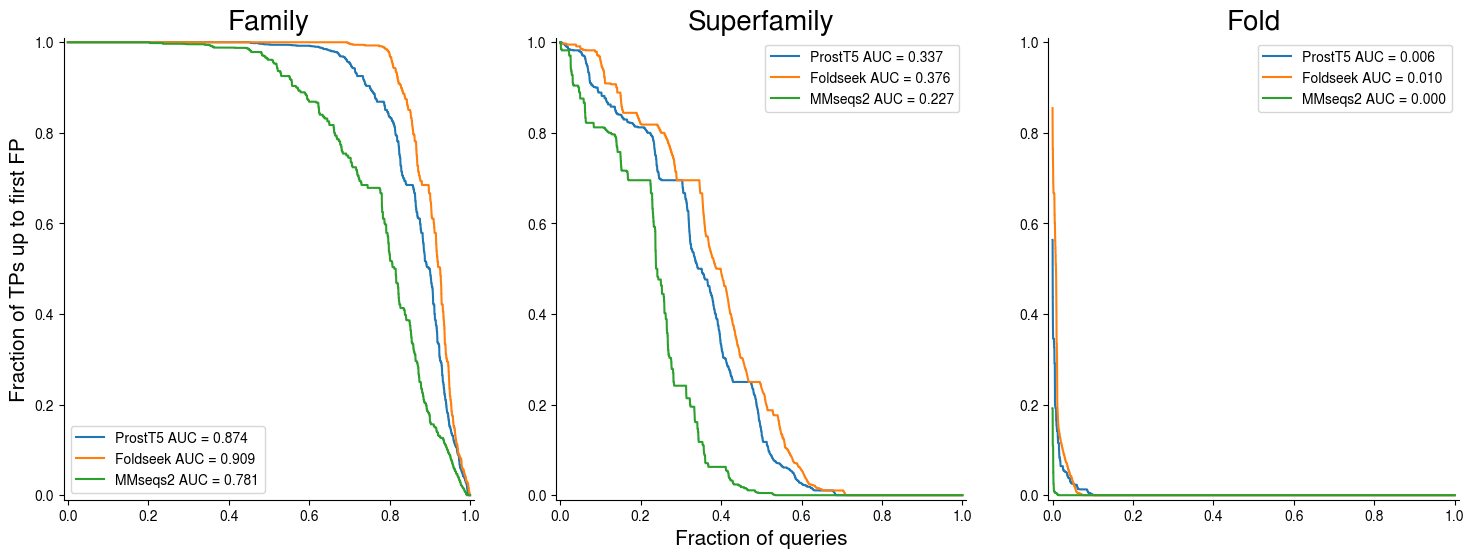

In [7]:
from matplotlib import pyplot as plt

# 1x3 subplots for family/superfamily/fold
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

# sort the file in descending order of 4th column, plot over query
# x-axis: fraction of queries, y-axis: fraction of TP up to first FP
def roc_plot(ax, file, tool):
    with open(file) as f:
        data = [line.strip().split() for line in f]
        data.sort(key=lambda x: float(x[3]), reverse=True)
        x = [1.0*(i+1)/len(data) for i in range(len(data))]
        y = [float(x[3]) for x in data]
        auc = sum(y) / len(y)
        ax.plot(x, y, label=f'{tool} AUC = {auc:.3f}')

# parse family-level results
axs[0].set_title('Family', fontsize=20)
roc_plot(axs[0], 'data/scope/scope40_viral_prostt5_fam.tsv', 'ProstT5')
roc_plot(axs[0], 'data/scope/scope40_viral_foldseek_fam.tsv', 'Foldseek')
roc_plot(axs[0], 'data/scope/scope40_viral_mmseqs_fam.tsv', 'MMseqs2')
    
# parse superfamily-level results
axs[1].set_title('Superfamily', fontsize=20)
roc_plot(axs[1], 'data/scope/scope40_viral_prostt5_sup.tsv', 'ProstT5')
roc_plot(axs[1], 'data/scope/scope40_viral_foldseek_sup.tsv', 'Foldseek')
roc_plot(axs[1], 'data/scope/scope40_viral_mmseqs_sup.tsv', 'MMseqs2')
    
# parse fold-level results
axs[2].set_title('Fold', fontsize=20)
roc_plot(axs[2], 'data/scope/scope40_viral_prostt5_fol.tsv', 'ProstT5')
roc_plot(axs[2], 'data/scope/scope40_viral_foldseek_fol.tsv', 'Foldseek')
roc_plot(axs[2], 'data/scope/scope40_viral_mmseqs_fol.tsv', 'MMseqs2')

axs[1].set_xlabel('Fraction of queries', fontsize=15)
axs[0].set_ylabel('Fraction of TPs up to first FP', fontsize=15)

for ax in axs:
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # set limit to 0 to 1
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    # show legend
    ax.legend()
plt.show()